In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import string
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud
nltk.download('stopwords')

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau

import warnings
warnings.filterwarnings('ignore')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\gab\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


<Axes: xlabel='Category', ylabel='count'>

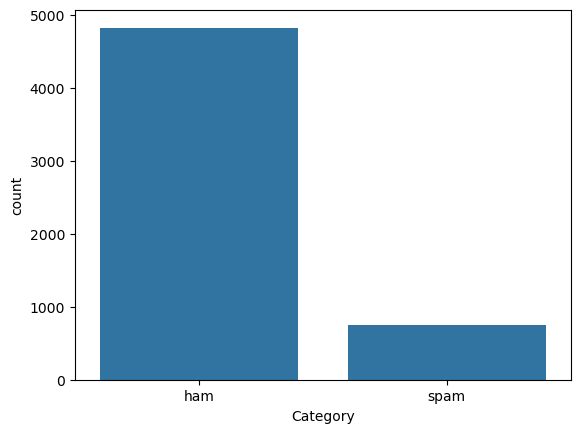

In [6]:
email=pd.read_csv('mail_data.csv')
email
sns.countplot(x='Category',data=email)



,Category,Message
0,ham,Can you pls send me that company name. In saib...
1,ham,Pls go there today &lt;#&gt; . I dont want an...
2,ham,Armand says get your ass over to epsilon
3,ham,Am on the uworld site. Am i buying the qbank o...
4,ham,I'm e person who's doing e sms survey...


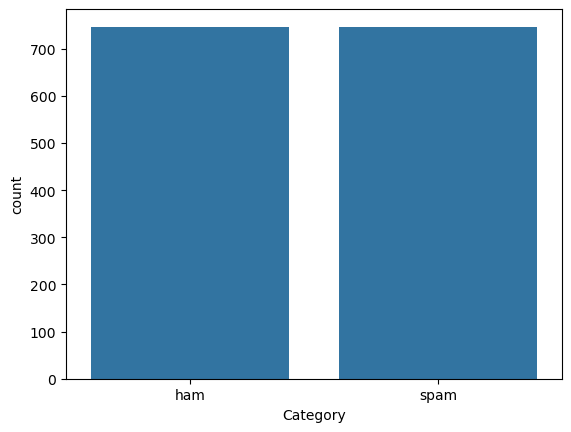

In [7]:
ham_msg=email[email['Category']=='ham']
spam_msg=email[email['Category']=='spam']
ham_msgb=ham_msg.sample(n=len(spam_msg),random_state=30)
email_bal=pd.concat([ham_msgb,spam_msg]).reset_index(drop=True)
sns.countplot(x='Category',data=email_bal)
email_bal.head(5)

In [8]:
punc_list=string.punctuation
def remove_punc(st):
    func=str.maketrans("","",punc_list)
    return st.translate(func)

email_bal['Message']=email_bal['Message'].apply(lambda x:remove_punc(x))
email_bal

,Category,Message
0,ham,Can you pls send me that company name In saiba...
1,ham,Pls go there today ltgt I dont want any excuses
2,ham,Armand says get your ass over to epsilon
3,ham,Am on the uworld site Am i buying the qbank on...
4,ham,Im e person whos doing e sms survey
...,...,...
1489,spam,Want explicit SEX in 30 secs Ring 02073162414 ...
1490,spam,ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE ...
1491,spam,Had your contract mobile 11 Mnths Latest Motor...
1492,spam,REMINDER FROM O2 To get 250 pounds free call c...


In [9]:
def remove_stpw(st):
    stpw=stopwords.words('english')
    colword=[]
    for word in str(st).split():
        word=word.lower()
        if word not in stpw:
            colword.append(word)

    output=" ".join(colword)
    return output

email_bal['Message']=email_bal['Message'].apply(lambda x: remove_stpw(x))
email_bal

            
    

,Category,Message
0,ham,pls send company name saibaba colany
1,ham,pls go today ltgt dont want excuses
2,ham,armand says get ass epsilon
3,ham,uworld site buying qbank buying self assessmen...
4,ham,im e person whos e sms survey
...,...,...
1489,spam,want explicit sex 30 secs ring 02073162414 cos...
1490,spam,asked 3mobile 0870 chatlines inclu free mins i...
1491,spam,contract mobile 11 mnths latest motorola nokia...
1492,spam,reminder o2 get 250 pounds free call credit de...


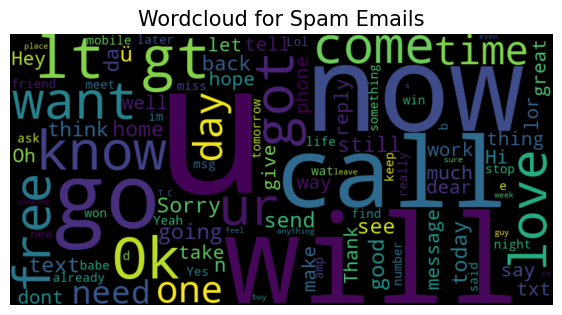

In [10]:
def word_cloud(data,typ):
    email_corp=" ".join(email['Message'])
    wc=WordCloud(background_color='black',max_words=100,height=400,width=800).generate(email_corp)
    plt.figure(figsize=(7,7))
    plt.imshow(wc,interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Wordcloud for {typ} Emails',fontsize=15)
    plt.show
               
word_cloud(email_bal[email_bal['Category']=='ham'],typ='Spam')


In [25]:
train_x,test_x,train_y,test_y=train_test_split(email_bal['Message'],email_bal['Category'],test_size=0.2,random_state=42)
tokenizer=Tokenizer(num_words=2000)
tokenizer.fit_on_texts(train_x)

test_sequence=tokenizer.texts_to_sequences(test_x)
train_sequence=tokenizer.texts_to_sequences(train_x)
test_sequence=pad_sequences(test_sequence,maxlen=100,padding='post',truncating='post')
train_sequence=pad_sequences(train_sequence,maxlen=100,padding='post',truncating='post')
train_y=(train_y=='spam').astype(int)
test_y=(test_y=='spam').astype(int)
                            

In [36]:
model=tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(100,)),
    tf.keras.layers.Embedding(len(tokenizer.word_index)+1,16),
    tf.keras.layers.GlobalAveragePooling1D(),
    tf.keras.layers.Dense(16,activation='relu'),
    tf.keras.layers.Dense(1,activation='sigmoid')
])

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)
#es=EarlyStopping(patience=3,monitor='val_accuracy',restore_best_weights=True)
#lr=ReduceLROnPlateau(patience=3,monitor='val_loss',factor=0.5,verbose=0)
history=model.fit(
    train_sequence,
    train_y,
    validation_data=(test_sequence,test_y),
    epochs=32,
    batch_size=20,
    #callbacks=[es,lr]
)


                        
                          
    

Epoch 1/32
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.5021 - loss: 0.6935 - val_accuracy: 0.4849 - val_loss: 0.6907
Epoch 2/32
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5038 - loss: 0.6864 - val_accuracy: 0.4849 - val_loss: 0.6897
Epoch 3/32
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5757 - loss: 0.6821 - val_accuracy: 0.5753 - val_loss: 0.6800
Epoch 4/32
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5866 - loss: 0.6704 - val_accuracy: 0.9298 - val_loss: 0.6684
Epoch 5/32
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6477 - loss: 0.6543 - val_accuracy: 0.6789 - val_loss: 0.6480
Epoch 6/32
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7933 - loss: 0.6164 - val_accuracy: 0.9097 - val_loss: 0.6057
Epoch 7/32
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8921 - loss: 0.5510 - val_accuracy: 0.6756 - val_loss: 0.5691
Epoch 8/32
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8837 - loss: 0.4747 - val_accuracy: 0.8963 - val_loss:

Text(0, 0.5, 'Accuracy')

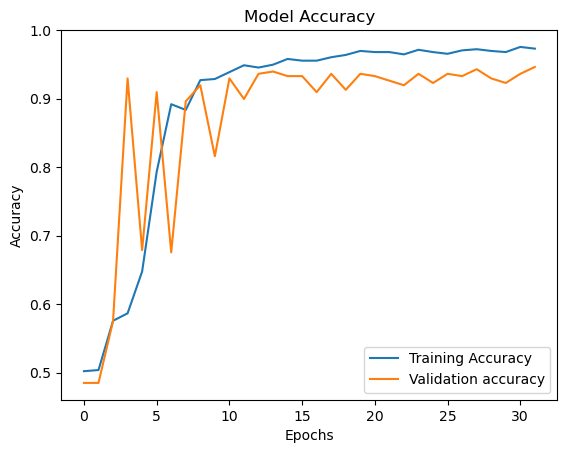

In [37]:
plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation accuracy')
plt.title('Model Accuracy')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
